In [ ]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer


from tqdm import tqdm
import os
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

from collections import defaultdict
from collections import Counter

import keras
from keras.models import Sequential
from keras.initializers import Constant
from keras.layers import (
    LSTM,
    Embedding,
    BatchNormalization,
    Dense,
    TimeDistributed,
    Dropout,
    Bidirectional,
    Flatten,
    GlobalMaxPool1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    accuracy_score,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# <p style="background-color:skyblue; font-family:newtimeroman; font-size:250%; text-align:center; border-radius: 15px 50px;">Natural Languague Processing 📝 A complete Guide</p>

**Natural Language Processing or NLP** is a branch of Artificial Intelligence which deal with bridging the machines understanding humans in their Natural Language. Natural Language can be in form of text or sound, which are used for humans to communicate each other. NLP can enable humans to communicate to machines in a natural way.

**Text Classification** is a process involved in Sentiment Analysis. It is classification of peoples opinion or expressions into different sentiments. Sentiments include Positive, Neutral, and Negative, Review Ratings and Happy, Sad. Sentiment Analysis can be done on different consumer centered industries to analyse people's opinion on a particular product or subject.

Natural language processing has its roots in the 1950s. Already in 1950, Alan Turing published an article titled "Computing Machinery and Intelligence" which proposed what is now called the Turing test as a criterion of intelligence, a task that involves the automated interpretation and generation of natural language, but at the time not articulated as a problem separate from artificial intelligence.

![Natural-Language-Processing.png](attachment:Natural-Language-Processing.png)

In this kernel we are going to focus on text classification and sentiment analysis part. In the next lessons we will study Information retrival, Question answering, etc

## <p style="background-color:skyblue; font-family:newtimeroman; font-size:120%; text-align:center; border-radius: 15px 50px;">Table of Content</p>

* [1. Loading Data 💎](#1)
* [2. EDA 📊](#2)
* [3. Data Preprocessing ⚙️](#3)
    * [3.1 Cleaning the corpus 🛠](#3.1)
    * [3.2 Stemming 🛠](#3.2)
    * [3.3 All together 🛠](#3.3)
    * [3.4 Target encoding 🛠](#3.4)
* [4. Tokens visualization 📊](#4)
* [5. Vectorization](#5)
    * [5.1 Tunning CountVectorizer](#5.1)
    * [5.2 TF-IDF](#5.2)
    * [5.3 Word Embeddings: GloVe](#5.3)
* [6. Modeling](#6)
    * [6.1 Naive Bayes DTM](#6.1)
    * [6.2 Naive Bayes TF-IDF](#6.2)
    * [6.3 XGBoost](#6.3)
* [7. LSTM](#7)
* [8. BERT](#8)
* [9. NLP: Disaster tweets](#9)
    * [9.1 EDA](#9.1)
    * [9.2 Data preprocessing](#9.2)
    * [9.3 WordCloud](#9.3)
    * [9.4 Modeling](#9.4)
    * [9.5 GloVe - LSTM](#9.5)

<a id='1'></a>
# <p style="background-color:skyblue; font-family:newtimeroman; font-size:150%; text-align:center; border-radius: 15px 50px;">1. Loading Data 💎</p>

Just load the dataset and global variables for colors and so on.

In [ ]:
# Defining all our palette colours.
primary_blue = "#496595"
primary_blue2 = "#85a1c1"
primary_blue3 = "#3f4d63"
primary_grey = "#c6ccd8"
primary_black = "#202022"
primary_bgcolor = "#f4f0ea"

primary_green = px.colors.qualitative.Plotly[2]

## Adapting the Code for Fake News Classification

First, let's load the `fake_or_real_news.csv` dataset and inspect its structure.

In [ ]:
df_fake = pd.read_csv('fake_or_real_news.csv', engine='python', on_bad_lines='skip')

# Display the first few rows and column information to understand the dataset structure
display(df_fake.head())
display(df_fake.info())

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6335 non-null   int64 
 1   title   6335 non-null   object
 2   text    6335 non-null   object
 3   label   6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


None

The dataset contains `title`, `text`, and `label` columns. For classification, we'll primarily use the `text` column as our message and `label` as our target. We will combine `title` and `text` for a richer input.

We need to rename the columns to `message` and `target` to align with the existing preprocessing functions.

In [ ]:
df_fake['full_text'] = df_fake['title'].fillna('') + ' ' + df_fake['text'].fillna('')
df_fake = df_fake[['full_text', 'label']]
df_fake.columns = ['message', 'target']

display(df_fake.head())

,message,target
0,You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE
2,Kerry to go to Paris in gesture of sympathy U....,REAL
3,Bernie supporters on Twitter erupt in anger ag...,FAKE
4,The Battle of New York: Why This Primary Matte...,REAL


Now, let's apply the same preprocessing steps (`message_len`, `clean_text`, `remove_stopwords`, `stemm_text`, `LabelEncoder`) to the new fake news DataFrame.

In [ ]:

# Ensure nltk stopwords and punkt are downloaded
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Define stop_words and stemmer globally or within the function if not already defined
stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords
stemmer = nltk.SnowballStemmer("english")

def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

def stemm_text(text):
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

# Calculate message length
df_fake['message_len'] = df_fake['message'].apply(lambda x: len(x.split(' ')))

# Clean the text
df_fake['message_clean'] = df_fake['message'].apply(clean_text)

# Remove stopwords
df_fake['message_clean'] = df_fake['message_clean'].apply(remove_stopwords)

# Stem the text
df_fake['message_clean'] = df_fake['message_clean'].apply(stemm_text)

# Encode the target variable
le_fake = LabelEncoder()
le_fake.fit(df_fake['target'])
df_fake['target_encoded'] = le_fake.transform(df_fake['target'])

display(df_fake.head())
display(le_fake.classes_)

,message,target,message_len,message_clean,target_encoded
0,You Can Smell Hillary’s Fear Daniel Greenfield...,FAKE,1303,smell hillari fear daniel greenfield shillman ...,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,FAKE,460,watch exact moment paul ryan commit polit suic...,0
2,Kerry to go to Paris in gesture of sympathy U....,REAL,432,kerri go pari gestur sympathi us secretari sta...,1
3,Bernie supporters on Twitter erupt in anger ag...,FAKE,419,berni support twitter erupt anger dnc tri warn...,0
4,The Battle of New York: Why This Primary Matte...,REAL,316,battl new york primari matter primari day new ...,1


array(['FAKE', 'REAL'], dtype=object)

Let's perform some basic EDA on the new dataset to check its balance and message lengths, similar to the original notebook.

In [ ]:
balance_counts_fake = df_fake.groupby('target')['target'].agg('count').values

fig = go.Figure()
fig.add_trace(go.Bar(
    x=['fake'],
    y=[balance_counts_fake[0]],
    name='fake',
    text=[balance_counts_fake[0]],
    textposition='auto',
    marker_color=primary_blue
))
fig.add_trace(go.Bar(
    x=['real'],
    y=[balance_counts_fake[1]],
    name='real',
    text=[balance_counts_fake[1]],
    textposition='auto',
    marker_color=primary_grey
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Dataset distribution by target (Fake News)</span>'
)
fig.show()

In [ ]:
fake_df_len = df_fake[df_fake['target'] == 'fake']['message_len'].value_counts().sort_index()
real_df_len = df_fake[df_fake['target'] == 'real']['message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fake_df_len.index,
    y=fake_df_len.values,
    name='fake',
    fill='tozeroy',
    marker_color=primary_blue,
))
fig.add_trace(go.Scatter(
    x=real_df_len.index,
    y=real_df_len.values,
    name='real',
    fill='tozeroy',
    marker_color=primary_grey,
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Message Length Distribution by Target (Fake News)</span>'
)
fig.update_xaxes(range=[0, 1000]) # Adjust range as fake news messages might be longer
fig.show()

Now we need to re-initialize the tokenizer and prepare the word embeddings for the fake news dataset. The `texts` and `target` variables will now refer to the `df_fake` DataFrame.

In [ ]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

texts_fake = df_fake['message_clean']
target_fake = df_fake['target_encoded']

# Calculate the length of our vocabulary for fake news data
word_tokenizer_fake = Tokenizer()
word_tokenizer_fake.fit_on_texts(texts_fake)

vocab_length_fake = len(word_tokenizer_fake.word_index) + 1
print(f"Vocabulary length for fake news dataset: {vocab_length_fake}")

# Define a maximum sequence length to prevent OOM errors
max_sequence_length_fake = 512 # Reduced from 10817
print(f"Using maximum sequence length for padding: {max_sequence_length_fake}")

train_padded_sentences_fake = pad_sequences(
    word_tokenizer_fake.texts_to_sequences(texts_fake),
    maxlen=max_sequence_length_fake,
    padding='post',
    truncating='post'
)

display(train_padded_sentences_fake)

Vocabulary length for fake news dataset: 128071
Using maximum sequence length for padding: 512


array([[5193,   23,  462, ...,  462,   63,  383],
       [ 416,  742,  490, ...,    0,    0,    0],
       [1372,   22,  861, ...,    0,    0,    0],
       ...,
       [2246,  297, 1550, ...,    2,   23,  838],
       [4437,   19,  585, ..., 1713,  191, 1325],
       [ 800,  116, 1629, ...,    0,    0,    0]], dtype=int32)

Next, we will generate the embedding matrix using the pre-trained GloVe embeddings and our new vocabulary.

In [ ]:
embeddings_dictionary = dict()
embedding_dim = 100 # Define embedding_dim for fake news embedding matrix

# Load GloVe 100D embeddings
with open("glove.6B.100d.txt", "r", encoding="utf8") as fp:
    for line in fp.readlines():
        records = line.split()
        word = records[0]
        vector_dimensions = np.asarray(records[1:], dtype='float32')
        embeddings_dictionary [word] = vector_dimensions

embedding_matrix_fake = np.zeros((vocab_length_fake, embedding_dim))

for word, index in word_tokenizer_fake.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix_fake[index] = embedding_vector

display(embedding_matrix_fake)

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.15730999, -0.75502998,  0.36844999, ..., -0.54136997,
         0.67817003, -0.17251   ],
       [-0.13128   , -0.45199999,  0.043399  , ..., -0.30526   ,
        -0.045495  ,  0.56509   ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.65482002, -0.64002001,  0.36364001, ...,  0.2579    ,
        -0.71521997, -0.50418001],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

Now, let's redefine the LSTM model to use the new `embedding_matrix_fake` and `length_long_sentence_fake`, and then split the data and train the model.

In [ ]:
def glove_lstm_fake_news(vocab_len, embedding_mat, sentence_len):
    model = Sequential()

    model.add(Embedding(
        input_dim=vocab_len,
        output_dim=embedding_mat.shape[1],
        weights=[embedding_mat],
        input_length=sentence_len, # Now uses the fixed max_sequence_length_fake
        trainable=False # Keep embeddings fixed
    ))

    model.add(Bidirectional(LSTM(
        128, # Reduced LSTM units significantly to avoid OOM
        return_sequences=True,
        recurrent_dropout=0.2
    )))

    model.add(GlobalMaxPool1D())
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu")) # Adjusted dense layer size
    model.add(Dropout(0.5))
    model.add(Dense(32, activation="relu")) # Adjusted dense layer size
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Split data for fake news classification
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(
    train_padded_sentences_fake,
    target_fake,
    test_size=0.05, # Using a smaller test size initially to speed up training for demonstration
    random_state=42
)

# Use the new max_sequence_length_fake for model initialization
model_fake_news = glove_lstm_fake_news(vocab_length_fake, embedding_matrix_fake, max_sequence_length_fake)
model_fake_news.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    12,807,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,807,100 (48.86 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 12,807,100 (48.86 MB)

In [ ]:
# Train the fake news classification model

checkpoint_fake = ModelCheckpoint(
    'model_fake_news.h5',
    monitor = 'val_loss',
    verbose = 1,
    save_best_only = True
)
reduce_lr_fake = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.2,
    verbose = 1,
    patience = 3, # Reduced patience for quicker demonstration
    min_lr = 0.0001
)
history_fake = model_fake_news.fit(
    X_train_fake,
    y_train_fake,
    epochs = 10, # Increased epochs but with early stopping due to reduce_lr_fake and checkpoint_fake
    batch_size = 64,
    validation_data = (X_test_fake, y_test_fake),
    verbose = 1,
    callbacks = [reduce_lr_fake, checkpoint_fake]
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6037 - loss: 0.8303
Epoch 1: val_loss improved from inf to 0.67128, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.6041 - loss: 0.8293 - val_accuracy: 0.7886 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7178 - loss: 0.5571
Epoch 2: val_loss improved from 0.67128 to 0.56204, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7180 - loss: 0.5569 - val_accuracy: 0.8360 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7811 - loss: 0.4729
Epoch 3: val_loss improved from 0.56204 to 0.47860, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.7813 - loss: 0.4727 - val_accuracy: 0.8454 - val_loss: 0.4786 - learning_rate: 0.0010
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8273 - loss: 0.3954
Epoch 4: val_loss improved from 0.47860 to 0.32913, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8273 - loss: 0.3954 - val_accuracy: 0.8927 - val_loss: 0.3291 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8456 - loss: 0.3468
Epoch 5: val_loss improved from 0.32913 to 0.27452, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8458 - loss: 0.3467 - val_accuracy: 0.8927 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8681 - loss: 0.3364
Epoch 6: val_loss improved from 0.27452 to 0.23751, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8682 - loss: 0.3361 - val_accuracy: 0.9117 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8869 - loss: 0.2771
Epoch 7: val_loss improved from 0.23751 to 0.18383, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8869 - loss: 0.2771 - val_accuracy: 0.9211 - val_loss: 0.1838 - learning_rate: 0.0010
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8960 - loss: 0.2506
Epoch 8: val_loss did not improve from 0.18383
95/95 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8960 - loss: 0.2506 - val_accuracy: 0.8959 - val_loss: 0.2067 - learning_rate: 0.0010
Epoch 9/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9202 - loss: 0.2149
Epoch 9: val_loss did not improve from 0.18383
95/95 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9201 - loss: 0.2150 - val_accuracy: 0.9180 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 10/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9216 - loss: 0.2079
Epoch 10: val_loss improved from 0.18383 to 0.16931, saving model to model_fake_news.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9216 - loss: 0.2078 - val_accuracy: 0.9306 - val_loss: 0.1693 - learning_rate: 0.0010


### Enhanced Learning Curves Plot

As requested, here's an improved version of the learning curve plot to visualize the training and validation loss and accuracy.

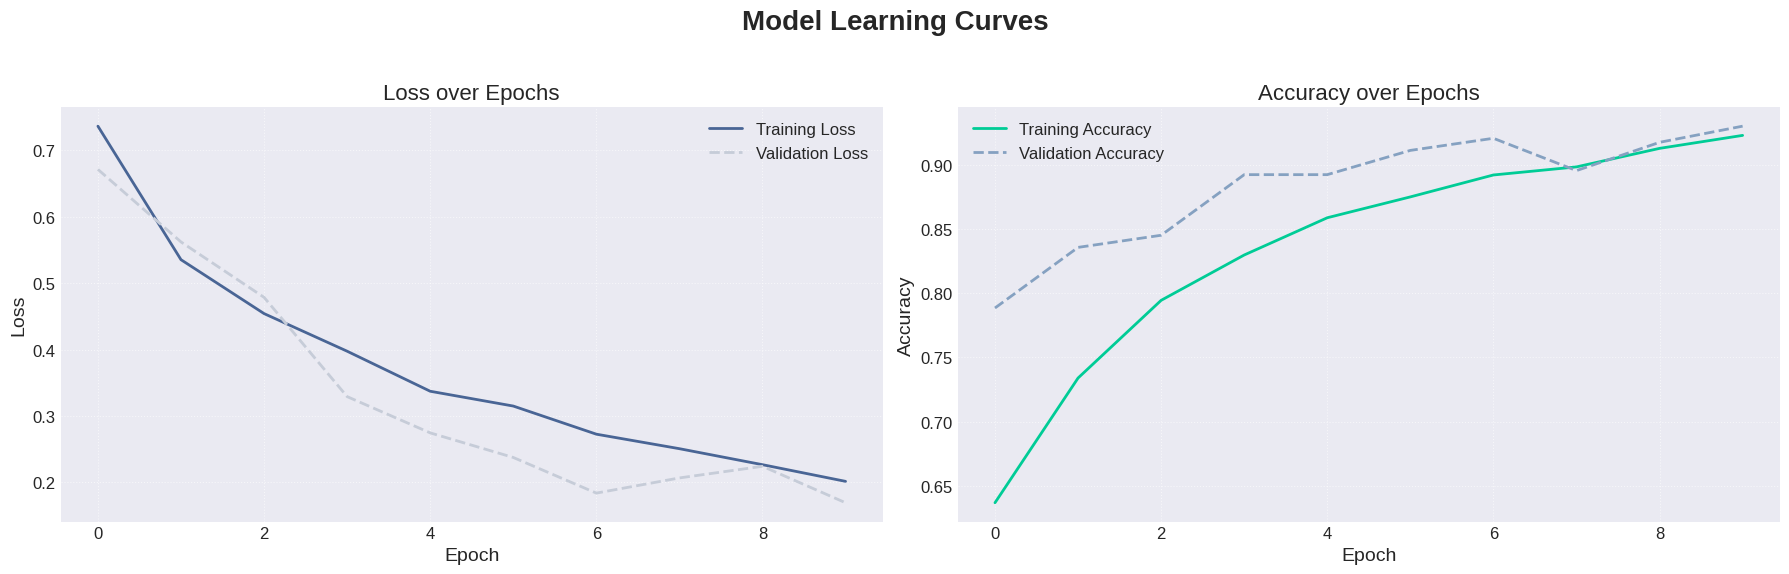

In [ ]:
def plot_enhanced_learning_curves(history):
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Model Learning Curves', fontsize=20, fontweight='bold')

    # Plot Loss
    ax[0].plot(history.history['loss'], label='Training Loss', color=primary_blue, linewidth=2)
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color=primary_grey, linewidth=2, linestyle='--')
    ax[0].set_title('Loss over Epochs', fontsize=16)
    ax[0].set_xlabel('Epoch', fontsize=14)
    ax[0].set_ylabel('Loss', fontsize=14)
    ax[0].legend(fontsize=12)
    ax[0].grid(True, linestyle=':', alpha=0.6)
    ax[0].tick_params(axis='both', which='major', labelsize=12)

    # Plot Accuracy
    ax[1].plot(history.history['accuracy'], label='Training Accuracy', color=primary_green, linewidth=2)
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color=primary_blue2, linewidth=2, linestyle='--')
    ax[1].set_title('Accuracy over Epochs', fontsize=16)
    ax[1].set_xlabel('Epoch', fontsize=14)
    ax[1].set_ylabel('Accuracy', fontsize=14)
    ax[1].legend(fontsize=12)
    ax[1].grid(True, linestyle=':', alpha=0.6)
    ax[1].tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

plot_enhanced_learning_curves(history_fake)

Finally, let's visualize the confusion matrix for the fake news classification model.

In [ ]:
import plotly.figure_factory as ff
from sklearn.metrics import confusion_matrix
import numpy as np

def conf_matrix(z, x, y):

    z = np.flip(z, 0)

    # change each element of z to type string for annotations
    z_text = [[str(y) for y in x] for x in z]

    # set up figure
    fig = ff.create_annotated_heatmap(z, x=x, y=y, annotation_text=z_text, colorscale='Viridis')

    # add title
    fig.update_layout(title_text='<b>Confusion matrix</b>',
                      xaxis = dict(title='Predicted value'),
                      yaxis = dict(title='Real value')
                     )

    # add colorbar
    fig['data'][0]['showscale'] = True

    return fig

y_preds_fake = (model_fake_news.predict(X_test_fake) > 0.5).astype("int32")
x_axes_fake = ['Fake', 'Real'] # Update x_axes for fake news classification
y_axes_fake = ['Real', 'Fake'] # Update y_axes for fake news classification
conf_matrix(confusion_matrix(y_test_fake, y_preds_fake), x=x_axes_fake, y=y_axes_fake)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step
